# Experiment: Levine32 Deconvolution with Latent Dimension 14

Objective:
- Load Levine32 and train the probabilistic archetypal autoencoder with latent dimension `K=14`.
- Save deconvolution outputs (cell weights, archetype profiles, diagnostics, and plots).


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'pyproject.toml').exists(), 'Could not find repo root with pyproject.toml'

SRC_PATH = REPO_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from cytof_archetypes.config import load_config
from cytof_archetypes.datasets import load_levine32_bundle
from cytof_archetypes.training import train_from_config, evaluate_run_dir

sns.set_theme(context='notebook', style='whitegrid')

# Render-stability defaults to reduce notebook jump/jitter while scrolling.
plt.ioff()
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 120
plt.rcParams['figure.autolayout'] = False
plt.rcParams['figure.constrained_layout.use'] = True

display(HTML("""
<style>
/* Reserve consistent output layout and avoid resize jitter in long notebooks. */
.jp-OutputArea-output,
.output_area {
  overflow-x: auto;
}
.jp-OutputArea-child,
.output_subarea {
  scroll-margin-top: 72px;
}
</style>
"""))


## Configure Data and Run

This follows the same pattern as your other notebook: define `DATA_DIR`, set `processed_path`, then load that prepared file.

In [2]:
# Levine32 prepared data path (same style as your 05_run_all_experiments notebook)
DATA_DIR = REPO_ROOT / "data"
processed_path = DATA_DIR / "levine32_processed.h5ad"

# Optional alternatives if you keep tabular exports instead of h5ad:
fallback_paths = [
    DATA_DIR / "levine32_processed.csv",
    DATA_DIR / "levine32_processed.tsv",
]
if not processed_path.exists():
    for p in fallback_paths:
        if p.exists():
            processed_path = p
            break

expected = [
    DATA_DIR / "levine32_processed.h5ad",
    DATA_DIR / "levine32_processed.csv",
    DATA_DIR / "levine32_processed.tsv",
]
assert processed_path.exists(), (
    "Missing Levine32 prepared file. Expected one of: "
    + ", ".join(str(x) for x in expected)
)
print(f"Using dataset: {processed_path}")

config = load_config(REPO_ROOT / "configs/levine32_default.yaml")
config["dataset"]["input_path"] = str(processed_path)
# In this model, latent dimension equals number of archetypes (simplex size).
config["model"]["n_archetypes"] = 14
config["output"]["run_name"] = None
config["training"]["max_epochs"] = 100
config["training"]["patience"] = 15
config["seed"] = 42

# Prefer MPS on Apple Silicon when available; otherwise keep auto.
import torch
if torch.backends.mps.is_available():
    config["device"] = "mps"
else:
    config["device"] = "auto"

print(f"Configured device request: {config['device']}")
config


Using dataset: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/levine32_processed.h5ad
Configured device request: mps


{'seed': 42,
 'device': 'mps',
 'dataset': {'name': 'levine32',
  'input_path': '/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/levine32_processed.h5ad',
  'marker_columns': None,
  'label_column': 'label',
  'cell_id_column': 'cell_id',
  'val_fraction': 0.15,
  'test_fraction': 0.15},
 'preprocessing': {'transform': 'arcsinh',
  'arcsinh_cofactor': 5.0,
  'normalization': 'zscore',
  'clip_min': -6.0,
  'clip_max': 6.0},
 'model': {'type': 'probabilistic_archetypal_autoencoder',
  'n_archetypes': 14,
  'encoder_hidden_dims': [128, 64],
  'activation': 'relu',
  'dropout': 0.1},
 'loss': {'type': 'gaussian_nll',
  'entropy_reg_weight': 0.001,
  'diversity_reg_weight': 0.001,
  'variance_reg_weight': 1e-05},
 'training': {'batch_size': 256,
  'lr': 0.0003,
  'weight_decay': 0.0001,
  'max_epochs': 100,
  'patience': 15,
  'grad_clip': 1.0,
  'mixed_precision': False},
 'output': {'base_dir': 'outputs', 'run_name': None}}

## Inspect Levine32 Before Training

In [3]:
bundle = load_levine32_bundle(
    input_path=processed_path,
    marker_columns=config["dataset"]["marker_columns"],
    label_column=config["dataset"]["label_column"],
    cell_id_column=config["dataset"]["cell_id_column"],
    val_fraction=config["dataset"]["val_fraction"],
    test_fraction=config["dataset"]["test_fraction"],
    seed=config["seed"],
)

print("train/val/test:", len(bundle.train.x), len(bundle.val.x), len(bundle.test.x))
print("n_markers:", len(bundle.markers))
print("first markers:", bundle.markers[:8])

if bundle.train.labels is not None:
    display(pd.Series(bundle.train.labels, name="label").value_counts())


train/val/test: 185938 39844 39845
n_markers: 32
first markers: ['CD45RA', 'CD133', 'CD19', 'CD22', 'CD11b', 'CD4', 'CD8', 'CD34']


label
nan                       113010
CD4_T_cells                18456
Monocytes                  14769
CD8_T_cells                14076
Mature_B_cells             11564
Pre_B_cells                 4295
CD16-_NK_cells              2733
CD34+CD38+CD123-_HSPCs      2307
CD16+_NK_cells              1574
pDCs                         866
Basophils                    845
CD34+CD38lo_HSCs             641
Pro_B_cells                  359
Plasma_B_cells               231
CD34+CD38+CD123+_HSPCs       212
Name: count, dtype: int64

## Train Or Load Existing Run (`latent dim = 14`)

This section lets you choose between:
- training a fresh model run, or
- loading a previously saved run directory to skip retraining.


In [4]:
# Toggle this to skip retraining and reuse an existing run directory.
USE_EXISTING_RUN = True

# Point this to the run directory you want to reuse.
EXISTING_RUN_DIR = REPO_ROOT / 'outputs' / 'Levine'

# Optional: if True, recompute evaluation artifacts from the saved checkpoint.
# Keep False when metrics/plots already exist and you only want to inspect outputs.
REBUILD_EVAL_OUTPUTS = True

if USE_EXISTING_RUN:
    run_dir = Path(EXISTING_RUN_DIR)
    assert run_dir.exists(), f'Run directory does not exist: {run_dir}'

    required_paths = [
        run_dir / 'config_resolved.yaml',
        run_dir / 'best_checkpoint.pt',
        run_dir / 'weights' / 'cell_weights_val.csv',
        run_dir / 'archetypes' / 'archetype_means.csv',
        run_dir / 'metrics' / 'val_metrics.json',
    ]
    missing = [p for p in required_paths if not p.exists()]
    if missing:
        raise FileNotFoundError(
            'Existing run is missing required files:\n' + '\n'.join(str(m) for m in missing)
        )

    print(f'Using existing run: {run_dir}')
    if REBUILD_EVAL_OUTPUTS:
        run_dir = evaluate_run_dir(run_dir=run_dir, checkpoint='best_checkpoint.pt')
        print('Rebuilt evaluation outputs from saved checkpoint.')
else:
    run_dir = train_from_config(config)
    print(f'Trained new run: {run_dir}')

run_dir


Using existing run: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/Levine


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Rebuilt evaluation outputs from saved checkpoint.


PosixPath('/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/Levine')

## Load Metrics and Training Log

In [5]:
run_dir = Path(run_dir)
training_log = pd.read_csv(run_dir / 'training_log.csv')
val_metrics = pd.read_json(run_dir / 'metrics/val_metrics.json', typ='series')
test_metrics = pd.read_json(run_dir / 'metrics/test_metrics.json', typ='series')

display(training_log.tail())
display(pd.DataFrame({'val': val_metrics, 'test': test_metrics}))

,epoch,train_loss,train_nll,train_entropy,train_diversity,train_var_reg,val_loss,val_nll,val_entropy,val_diversity,val_var_reg
95,96,12.652112,12.650261,1.685393,0.012146,15.285554,10.052657,10.050812,1.679401,0.012173,15.339606
96,97,12.601295,12.599443,1.685642,0.012271,15.393516,9.966111,9.964265,1.679181,0.012455,15.449363
97,98,12.541574,12.539721,1.685580,0.012761,15.506308,9.888923,9.887076,1.677982,0.013135,15.566063
98,99,12.485151,12.483294,1.687680,0.013496,15.627128,9.824413,9.822553,1.689524,0.013810,15.686774
99,100,12.429095,12.427233,1.690340,0.014069,15.748631,9.749215,9.747356,1.686888,0.014299,15.810503


,val,test
class_Basophils_mse,0.589656,0.614579
class_Basophils_nll,15.293232,15.115986
class_CD16+_NK_cells_mse,0.795043,0.796977
class_CD16+_NK_cells_nll,10.792442,10.562432
class_CD16-_NK_cells_mse,0.769492,0.776564
...,...,...
marker_31_mse,0.081596,0.085590
mse_mean,0.535451,0.533413
mse_std,0.341549,0.339761
nll_mean,9.747355,9.769759


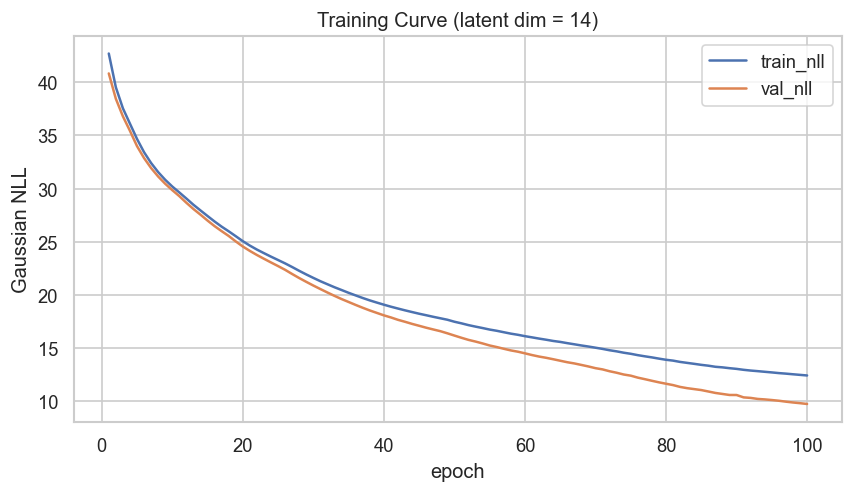

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(training_log['epoch'], training_log['train_nll'], label='train_nll')
ax.plot(training_log['epoch'], training_log['val_nll'], label='val_nll')
ax.set_title('Training Curve (latent dim = 14)')
ax.set_xlabel('epoch')
ax.set_ylabel('Gaussian NLL')
ax.legend()
plt.show()

## Archetype Profiles (Means and Variances)

In [7]:
means = pd.read_csv(run_dir / 'archetypes/archetype_means.csv', index_col=0)
vars_df = pd.read_csv(run_dir / 'archetypes/archetype_vars.csv', index_col=0)

display(means.head())
display(vars_df.head())

,CD45RA,CD133,CD19,CD22,CD11b,CD4,CD8,CD34,Flt3,CD20,...,CD44,CD38,CD13,CD3,CD61,CD117,CD49d,HLA-DR,CD64,CD41
arch_0,0.337187,-1.548889,-0.649093,-0.786731,-0.447959,-0.163417,-0.265445,-0.819792,-1.181720,-0.633954,...,0.443088,-0.863767,-0.993948,-1.016561,-1.082209,-0.641732,-1.806612,-0.831150,-0.673025,-0.531507
arch_1,0.016930,-0.548137,0.841250,1.704406,-2.331553,0.108740,0.111586,1.659484,0.145741,2.679210,...,0.469750,-1.240035,-1.550897,-0.093386,-0.229591,0.327554,1.166975,-0.581288,2.864235,-0.631100
arch_2,0.197980,0.469627,-0.576399,-0.204937,-0.068980,-0.127863,-0.377010,0.195280,0.517886,-0.305474,...,-0.092834,0.023728,0.424862,-0.806483,4.413806,-0.468279,1.880446,-0.143411,-0.433803,9.877623
arch_3,2.263950,-0.934960,5.212764,4.028946,-0.888063,-1.241636,-0.907993,-0.273202,-0.837999,2.606008,...,-0.013065,-0.131549,-0.728615,-0.949108,-0.711339,-0.570095,-0.717334,4.259197,-0.662701,-0.505144
arch_4,1.115104,4.426600,-0.606123,0.918585,0.790699,0.401272,0.060772,1.215662,3.327015,0.748029,...,1.942580,-1.857230,-1.246486,-0.927462,0.466146,-0.559668,3.436280,-0.641009,-0.644800,-0.501158


,CD45RA,CD133,CD19,CD22,CD11b,CD4,CD8,CD34,Flt3,CD20,...,CD44,CD38,CD13,CD3,CD61,CD117,CD49d,HLA-DR,CD64,CD41
arch_0,2.434717,8.036183e-04,0.000073,0.000186,0.024989,1.731912,0.626733,0.009140,0.022600,0.000452,...,1.115598,0.262437,0.038784,0.003250,0.001362,0.000229,0.117995,0.002187,0.000039,0.000032
arch_1,0.977993,4.642697e-01,4.512712,0.958813,0.848001,2.314144,2.824131,0.802887,0.574493,3.477226,...,0.396933,0.282590,0.517771,2.497898,0.586280,1.435721,0.877777,0.701297,3.229262,0.320288
arch_2,0.627638,2.375117e+00,0.032857,0.951077,0.201430,0.889309,0.148676,0.340162,1.020990,1.017450,...,0.195883,0.096788,0.754987,0.107871,4983.080000,0.006408,2.398031,0.312119,0.117267,103211.210000
arch_3,1.537950,3.574927e-02,752.646900,92.013336,0.014828,0.001841,0.000031,0.091522,0.059933,102.724000,...,0.491335,1.372607,0.140938,0.000189,0.062789,0.002056,0.315962,4.520054,0.000431,0.011084
arch_4,1.397057,1.257693e+06,0.070324,41847.230000,16.771414,8.508792,51.377514,36.531975,3554.260700,131981.330000,...,0.603858,0.039402,0.057078,0.018104,2.367172,0.000572,18.068258,0.484029,0.016555,0.002117


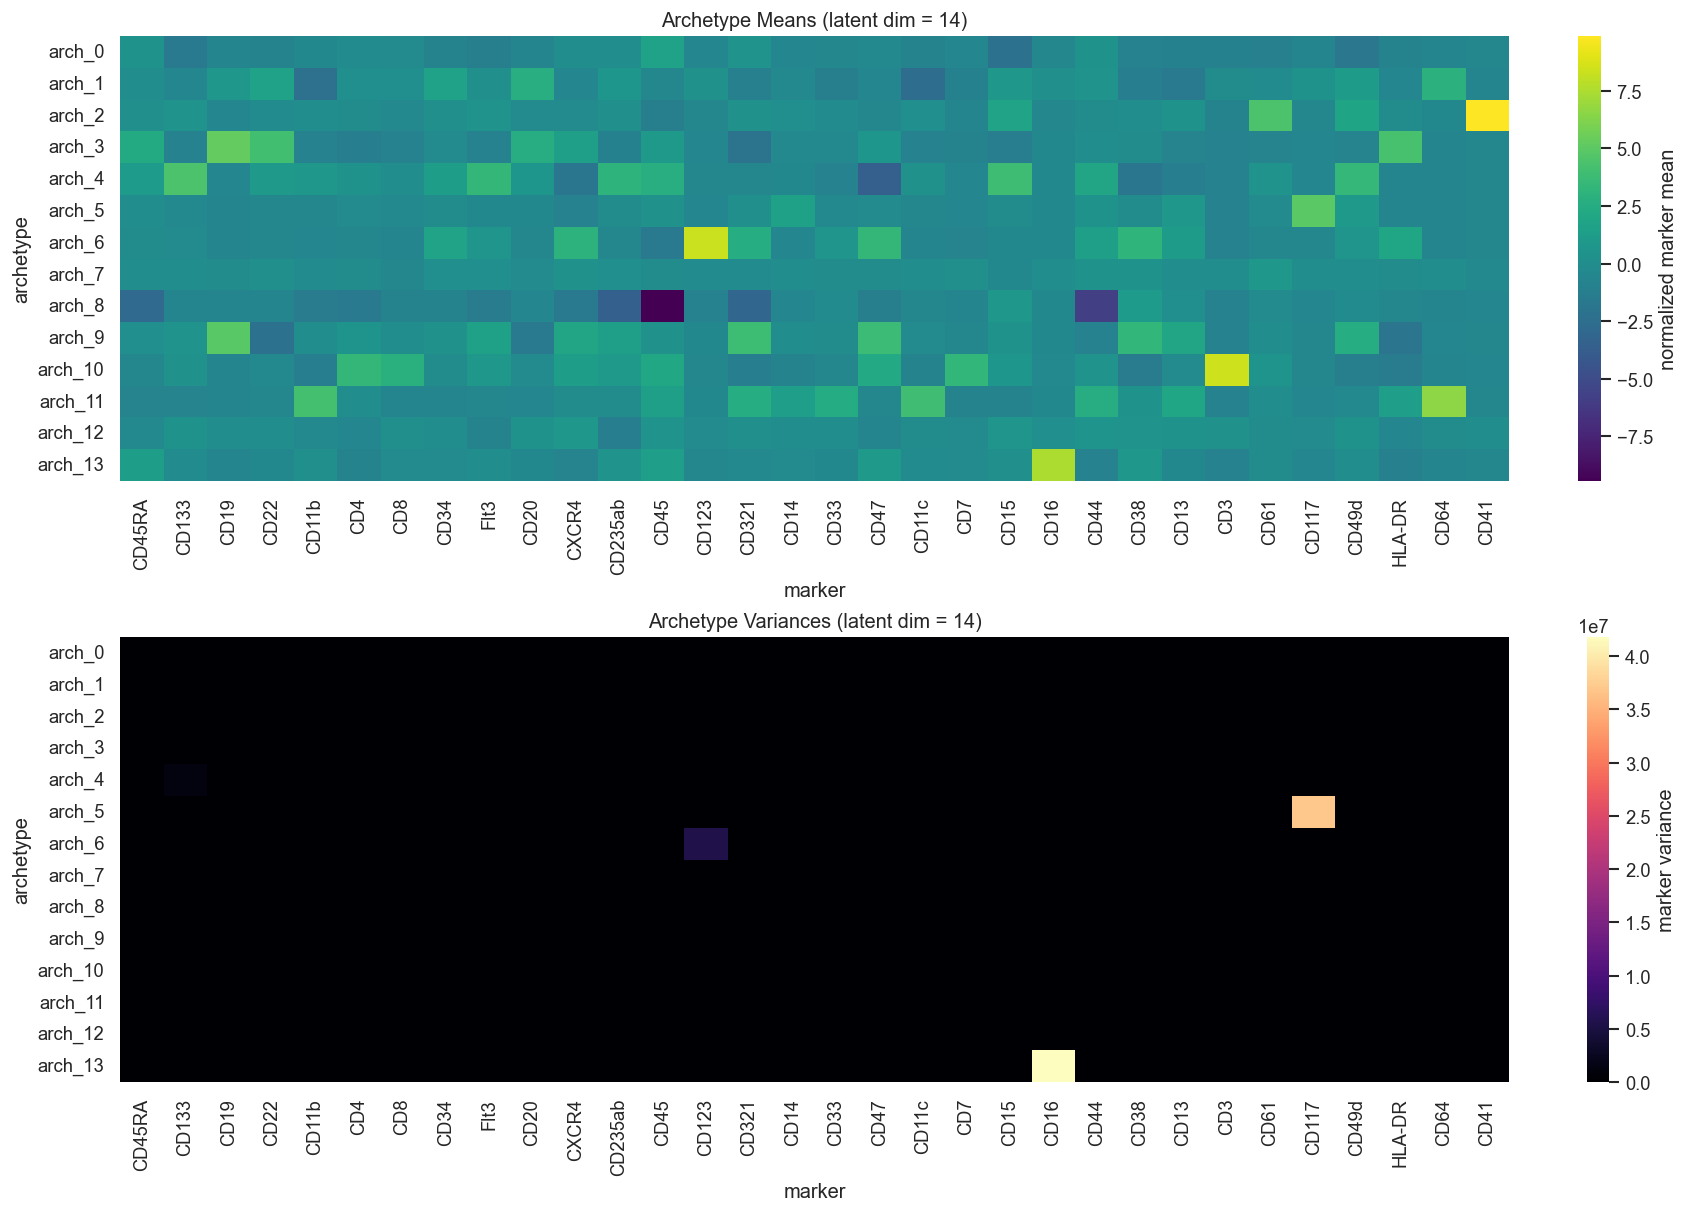

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

sns.heatmap(
    means,
    cmap='viridis',
    ax=axes[0],
    cbar_kws={'label': 'normalized marker mean'},
    linewidths=0,
)
axes[0].set_title('Archetype Means (latent dim = 14)')
axes[0].set_ylabel('archetype')
axes[0].set_xlabel('marker')
axes[0].grid(False)

sns.heatmap(
    vars_df,
    cmap='magma',
    ax=axes[1],
    cbar_kws={'label': 'marker variance'},
    linewidths=0,
)
axes[1].set_title('Archetype Variances (latent dim = 14)')
axes[1].set_ylabel('archetype')
axes[1].set_xlabel('marker')
axes[1].grid(False)

plt.show()


## Cell-Wise Deconvolution Weights

Constructed AnnData for deconvolution: 39,844 cells
  - X shape (cells x markers): (39844, 32)
  - marker count in var_names: 32
  - weights in obs columns: 14
  - current obsm keys: ['X_weights']


,cell_id,cell_type,dominant_archetype,w_0,w_1,w_2,w_3
cell_131910,cell_131910,unassigned,w_11,0.097514,4.002050e-04,0.035695,4.806951e-03
cell_261900,cell_261900,unassigned,w_0,0.528648,4.050852e-07,0.001678,2.833727e-09
cell_43556,cell_43556,Mature_B_cells,w_3,0.091665,1.438849e-02,0.078399,3.587943e-01
cell_120449,cell_120449,unassigned,w_10,0.185477,2.957913e-05,0.001280,2.058795e-06
cell_241293,cell_241293,unassigned,w_0,0.415218,1.524036e-06,0.000451,2.285087e-07


,mean,std,min,max
w_0,2.362972e-01,1.432310e-01,1.347846e-05,0.759275
w_1,2.230558e-03,5.833291e-03,1.073973e-10,0.105407
w_2,4.425345e-02,6.903765e-02,6.722568e-06,0.570993
w_3,7.084983e-02,1.322963e-01,5.557870e-14,0.552399
w_4,1.030370e-01,6.555992e-02,2.556996e-06,0.485917
w_5,7.789955e-02,8.592276e-02,2.346604e-06,0.499333
w_6,6.318645e-02,9.418765e-02,6.252902e-05,0.581414
w_7,3.553291e-09,2.474069e-08,6.982664e-29,0.000002
w_8,1.084047e-01,7.005824e-02,5.628398e-12,0.537684
w_9,3.494698e-02,4.483829e-02,1.448480e-05,0.438385


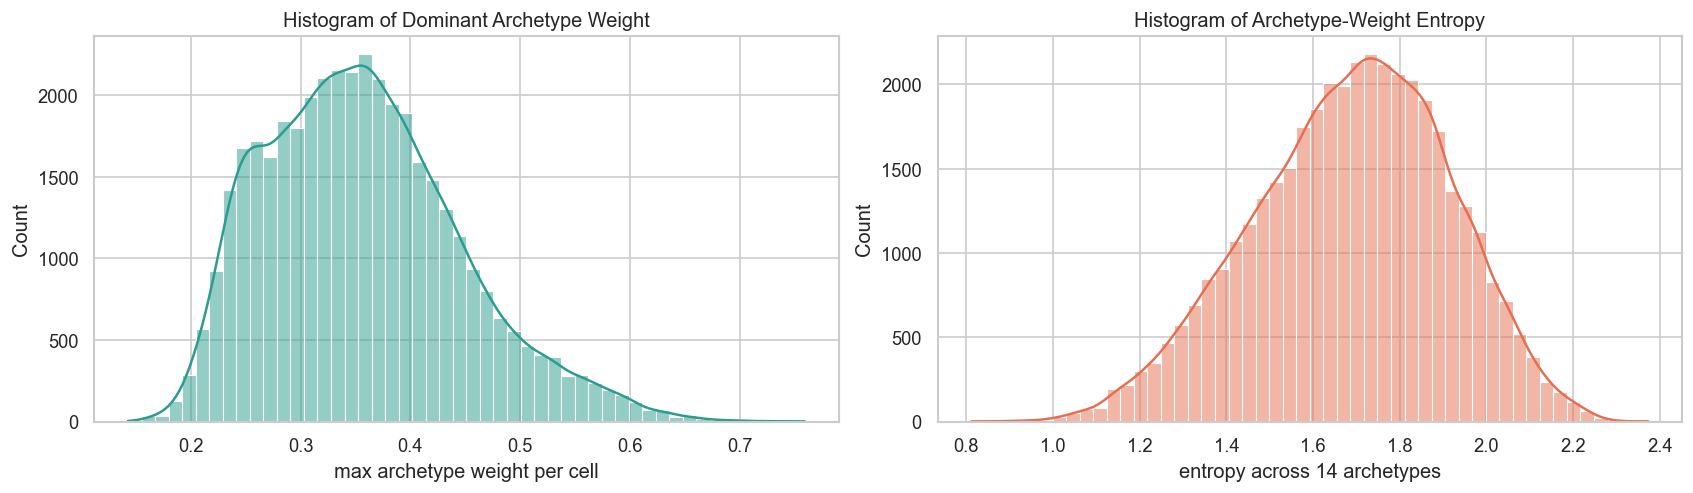

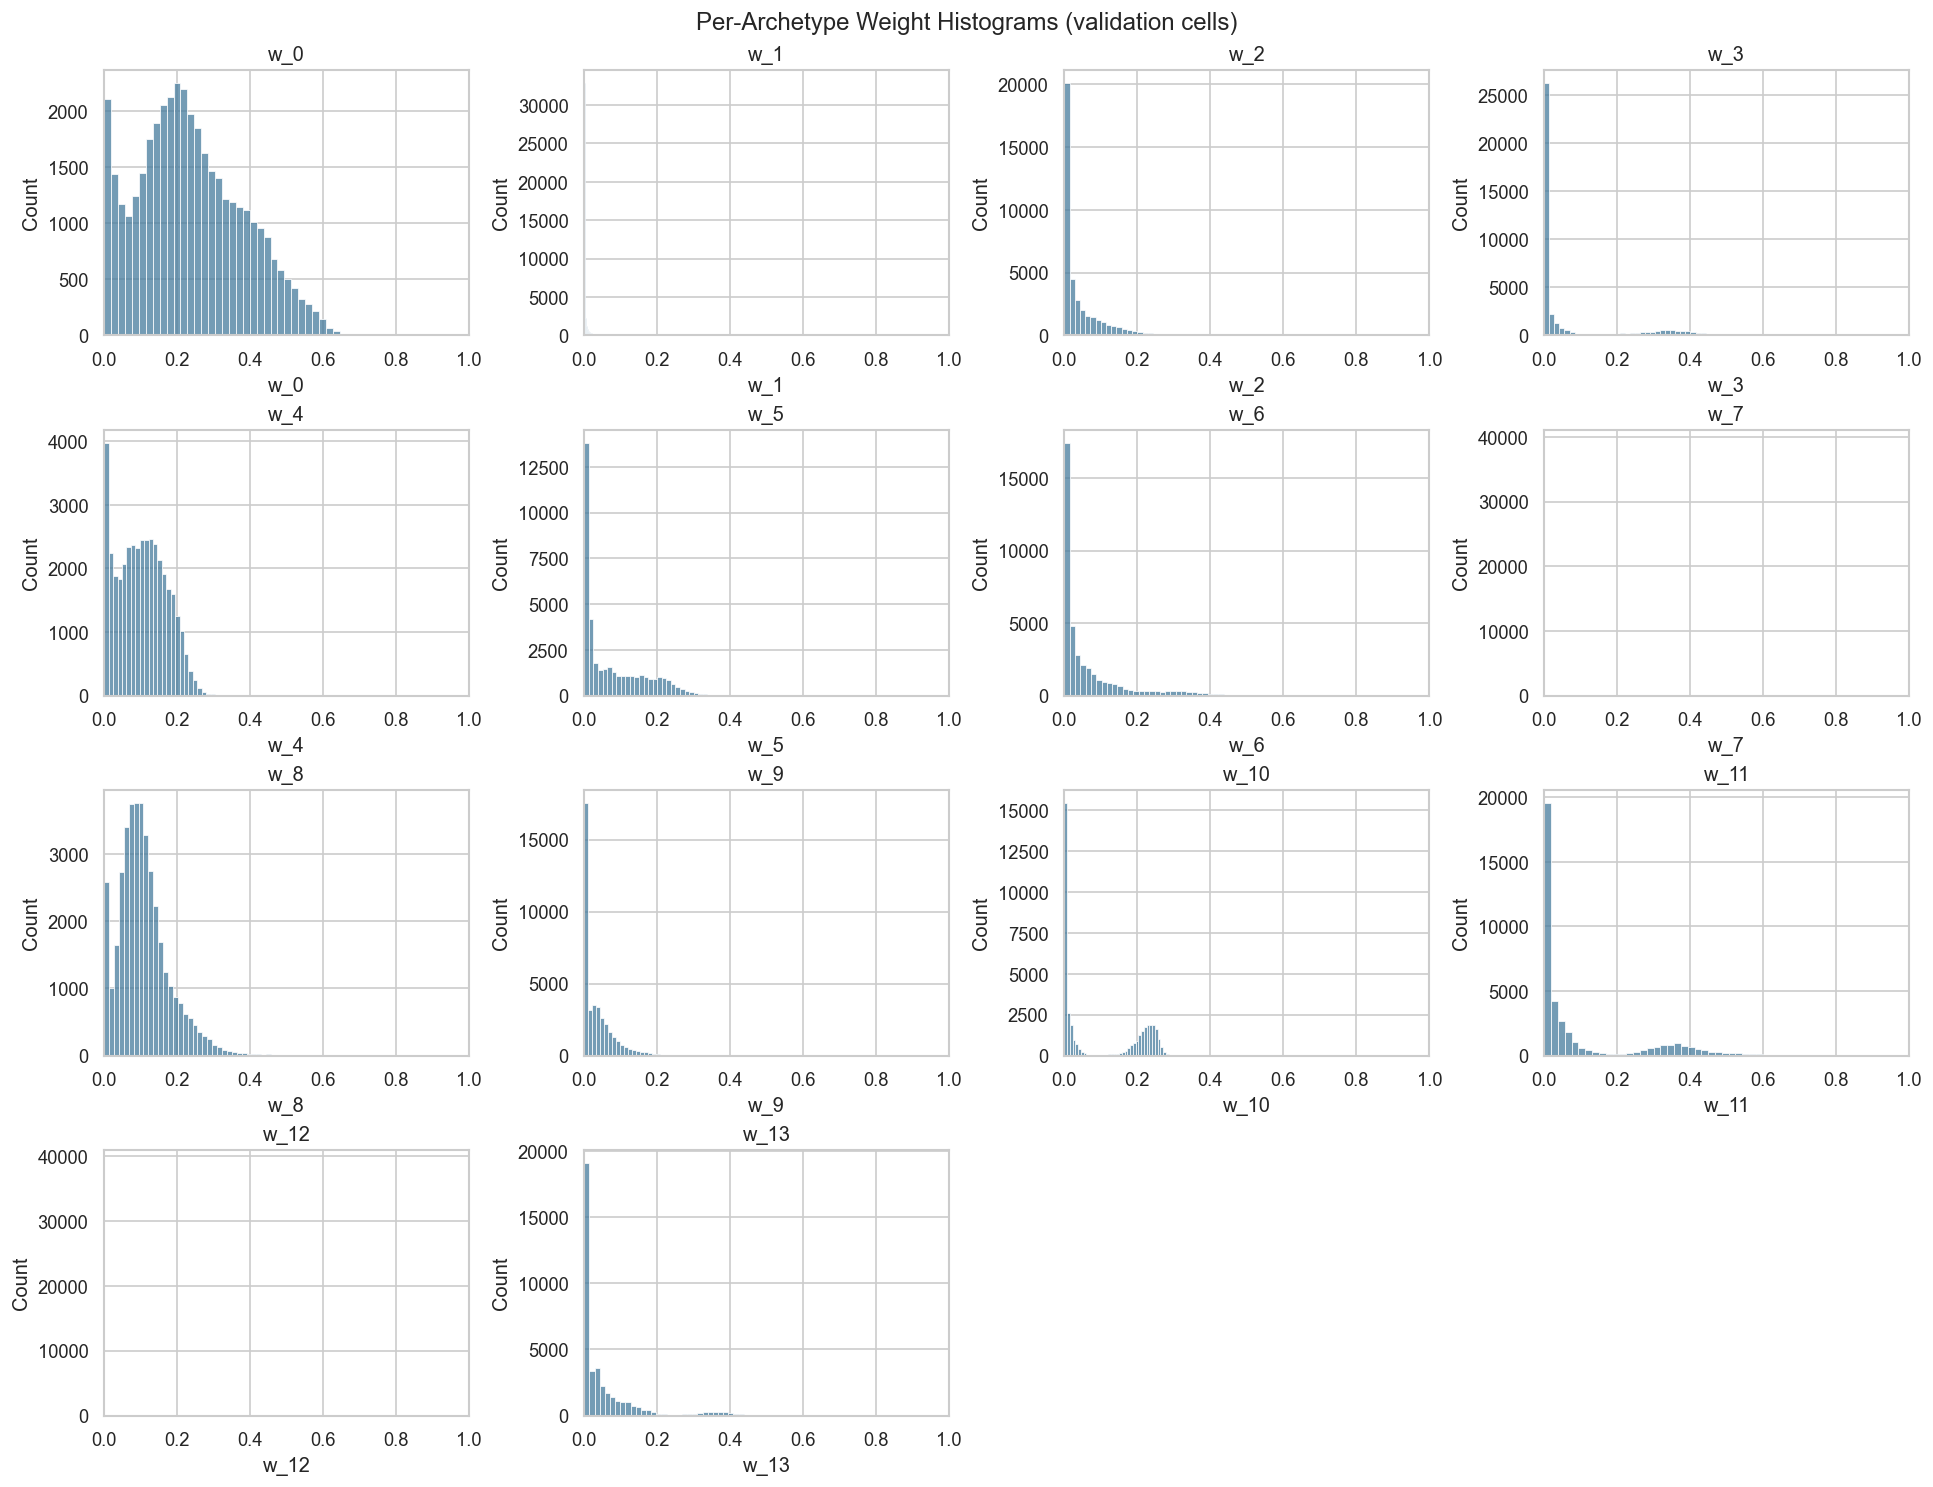

In [9]:
import anndata as ad

cell_weights_df = pd.read_csv(run_dir / 'weights/cell_weights_val.csv')
weight_cols = [c for c in cell_weights_df.columns if c.startswith('w_')]

if 'cell_id' in cell_weights_df.columns:
    cell_ids = cell_weights_df['cell_id'].astype(str)
else:
    cell_ids = pd.Series([f'cell_{i}' for i in range(len(cell_weights_df))], name='cell_id')

if 'label' in cell_weights_df.columns:
    cell_type = cell_weights_df['label'].fillna('unassigned').astype(str)
else:
    cell_type = pd.Series(['unknown'] * len(cell_weights_df), name='cell_type')

# Pull marker matrix from the loaded validation split and align by cell_id.
cell_id_col = config['dataset']['cell_id_column']
marker_cols = list(bundle.markers)
val_marker_df = bundle.val.frame[[cell_id_col] + marker_cols].copy()
val_marker_df[cell_id_col] = val_marker_df[cell_id_col].astype(str)
val_marker_df = val_marker_df.set_index(cell_id_col)

marker_aligned = val_marker_df.reindex(cell_ids.values)
missing_rows = marker_aligned.index[marker_aligned.isna().all(axis=1)]
if len(missing_rows) > 0:
    raise ValueError(
        f'Could not align {len(missing_rows)} cells between weight file and validation marker table.'
    )
marker_matrix = marker_aligned[marker_cols].to_numpy(dtype=np.float32)

obs_df = pd.DataFrame(index=cell_ids.values)
obs_df['cell_id'] = cell_ids.values
obs_df['cell_type'] = cell_type.values
for col in weight_cols:
    obs_df[col] = cell_weights_df[col].astype(np.float32).values

obs_df['max_weight'] = obs_df[weight_cols].max(axis=1)
obs_df['weight_entropy'] = -(obs_df[weight_cols] * np.log(obs_df[weight_cols] + 1e-10)).sum(axis=1)
obs_df['dominant_archetype'] = obs_df[weight_cols].idxmax(axis=1)

# Keep deconvolution data in AnnData:
# - marker matrix in X
# - marker names in var_names
# - labels + weights in obs
# - latent embeddings in obsm
adata_deconv = ad.AnnData(
    X=marker_matrix,
    obs=obs_df,
)
adata_deconv.var_names = marker_cols
adata_deconv.obsm['X_weights'] = obs_df[weight_cols].to_numpy(dtype=np.float32)

print(f'Constructed AnnData for deconvolution: {adata_deconv.n_obs:,} cells')
print(f'  - X shape (cells x markers): {adata_deconv.X.shape}')
print(f'  - marker count in var_names: {adata_deconv.n_vars}')
print(f'  - weights in obs columns: {len(weight_cols)}')
print(f'  - current obsm keys: {list(adata_deconv.obsm.keys())}')

display(adata_deconv.obs[['cell_id', 'cell_type', 'dominant_archetype'] + weight_cols[:4]].head())
display(adata_deconv.obs[weight_cols].describe().T[['mean', 'std', 'min', 'max']])

# Histogram diagnostics from AnnData.obs
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
sns.histplot(adata_deconv.obs['max_weight'], bins=50, kde=True, color='#2a9d8f', ax=axes[0])
axes[0].set_title('Histogram of Dominant Archetype Weight')
axes[0].set_xlabel('max archetype weight per cell')

sns.histplot(adata_deconv.obs['weight_entropy'], bins=50, kde=True, color='#e76f51', ax=axes[1])
axes[1].set_title('Histogram of Archetype-Weight Entropy')
axes[1].set_xlabel('entropy across 14 archetypes')
plt.show()

# Per-archetype histograms (sampled for readability)
plot_obs = adata_deconv.obs.sample(n=min(adata_deconv.n_obs, 50000), random_state=42)
fig, axes = plt.subplots(4, 4, figsize=(16, 12), constrained_layout=True)
axes = axes.flatten()
for i, col in enumerate(weight_cols):
    sns.histplot(plot_obs[col], bins=40, kde=False, color='#457b9d', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlim(0, 1)

for j in range(len(weight_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Per-Archetype Weight Histograms (validation cells)', y=1.02)
plt.show()


,w_0,w_1,w_2,w_3,w_4,w_5,w_6,w_7,w_8,w_9,w_10,w_11,w_12,w_13
cell_type,,,,,,,,,,,,,,
Basophils,0.198761,0.000126,0.050339,0.004781,0.090425,0.052760,0.344215,5.971130e-11,0.150488,0.018373,0.008607,0.030096,6.118495e-11,0.051029
CD16+_NK_cells,0.300674,0.000369,0.021434,0.005898,0.106459,0.032983,0.018261,2.331231e-11,0.084529,0.023226,0.009624,0.016924,1.426402e-11,0.379618
CD16-_NK_cells,0.327009,0.000408,0.019654,0.005326,0.106667,0.040577,0.018621,2.532232e-10,0.096581,0.021565,0.008656,0.015738,2.629122e-10,0.339197
CD34+CD38+CD123+_HSPCs,0.127849,0.000119,0.044694,0.005588,0.088063,0.066191,0.372291,5.229425e-12,0.209917,0.013265,0.004063,0.021297,7.419122e-12,0.046662
CD34+CD38+CD123-_HSPCs,0.059675,0.000206,0.036695,0.005570,0.059117,0.203440,0.334990,2.171788e-11,0.216440,0.021306,0.005051,0.018336,2.450907e-11,0.039174
CD34+CD38lo_HSCs,0.073789,0.000226,0.029925,0.006879,0.087232,0.219244,0.303511,9.535118e-11,0.195884,0.017534,0.006707,0.021267,1.401294e-10,0.037802
CD4_T_cells,0.360522,0.000736,0.019412,0.006595,0.090871,0.117534,0.020151,2.149114e-09,0.090758,0.019410,0.228513,0.015180,4.391580e-09,0.030319
CD8_T_cells,0.353996,0.001076,0.017699,0.009706,0.122034,0.109993,0.018676,3.328733e-09,0.083911,0.023965,0.216989,0.013398,6.928388e-09,0.028559
Mature_B_cells,0.164392,0.010509,0.043164,0.355082,0.148812,0.037754,0.026018,1.299466e-08,0.084682,0.055647,0.008608,0.027457,2.298071e-08,0.037875


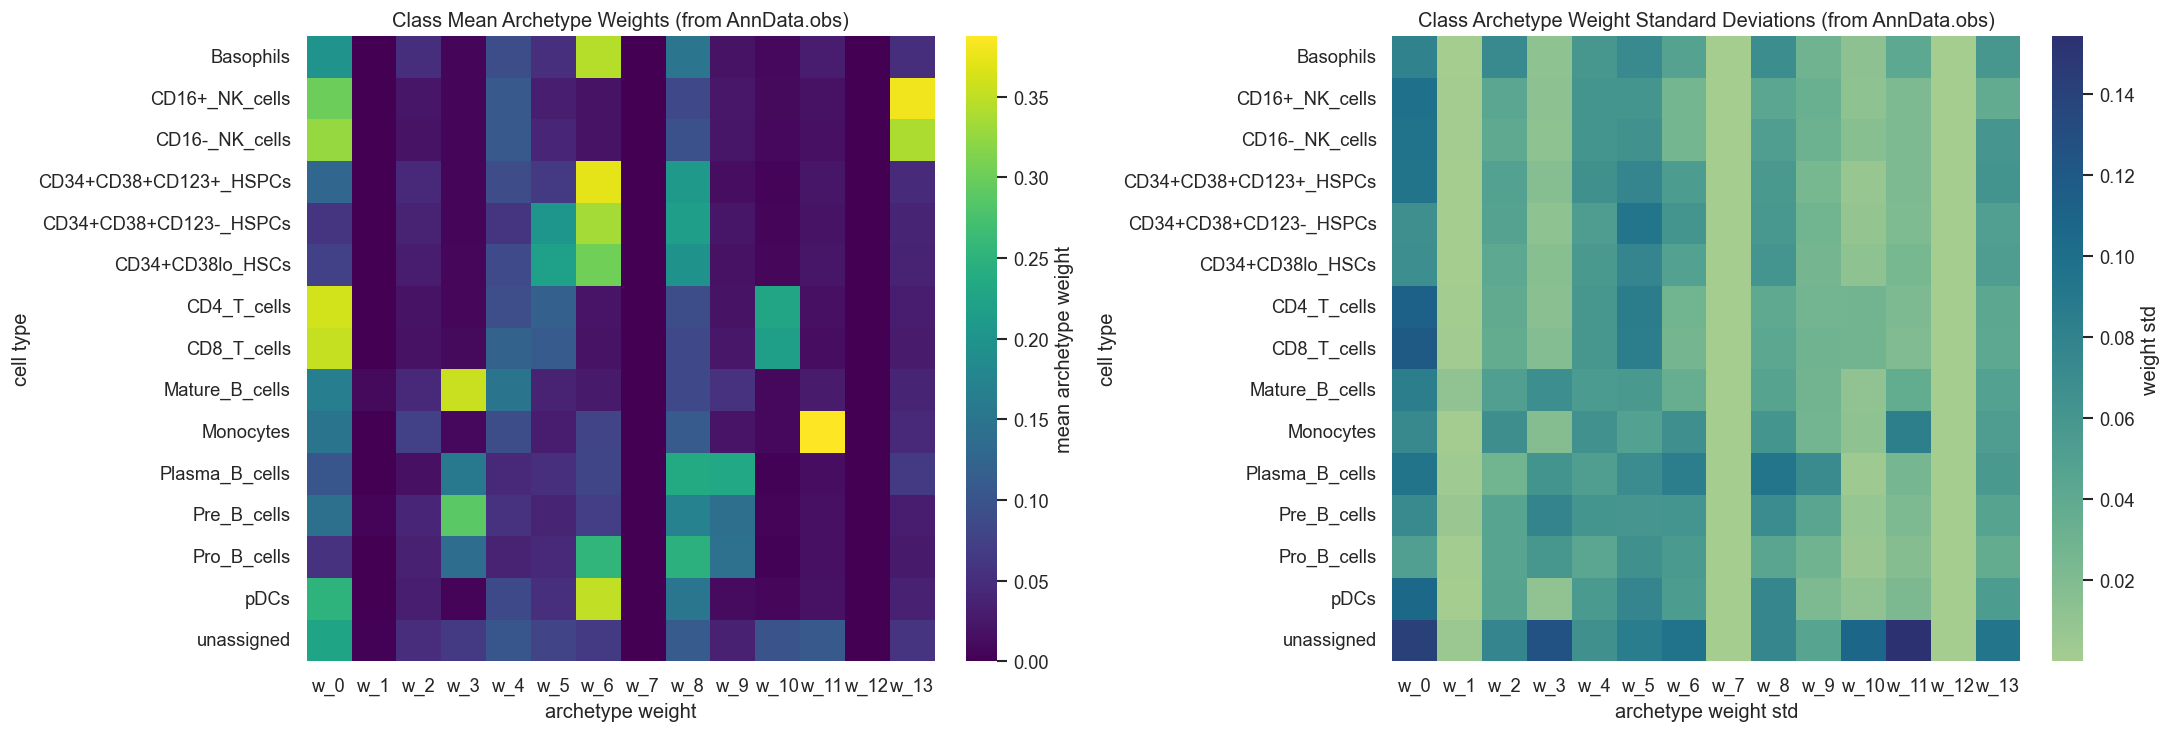

In [10]:
# Class-level summaries derived directly from AnnData.obs
mean_by_type = adata_deconv.obs.groupby('cell_type')[weight_cols].mean().sort_index()
std_by_type = adata_deconv.obs.groupby('cell_type')[weight_cols].std().sort_index().fillna(0.0)

display(mean_by_type)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

sns.heatmap(
    mean_by_type,
    cmap='viridis',
    ax=axes[0],
    cbar_kws={'label': 'mean archetype weight'},
    linewidths=0,
)
axes[0].set_title('Class Mean Archetype Weights (from AnnData.obs)')
axes[0].set_xlabel('archetype weight')
axes[0].set_ylabel('cell type')
axes[0].grid(False)

sns.heatmap(
    std_by_type,
    cmap='crest',
    ax=axes[1],
    cbar_kws={'label': 'weight std'},
    linewidths=0,
)
axes[1].set_title('Class Archetype Weight Standard Deviations (from AnnData.obs)')
axes[1].set_xlabel('archetype weight std')
axes[1].set_ylabel('cell type')
axes[1].grid(False)

plt.show()


## UMAP on AnnData Cell-Weight Embeddings (Scanpy, Colored by Cell Type)

This section keeps the latent deconvolution representation inside `AnnData` as requested:

- `adata_deconv.obs`: labels and per-cell archetype weights (`w_*`)
- `adata_deconv.obsm['X_weights']`: numeric weight matrix used for neighbor graph
- `adata_deconv.obsm['X_weights_pca']`: PCA embedding of weight space
- `adata_deconv.obsm['X_umap']` and `adata_deconv.obsm['X_umap_weights']`: 2D UMAP embeddings for plotting

The Scanpy configuration is printed verbosely for transparency and reproducibility.


In [11]:
try:
    import scanpy as sc
except ImportError as exc:
    raise ImportError(
        'scanpy is required for this UMAP section. Install with: pip install scanpy'
    ) from exc

from sklearn.decomposition import PCA

adata_deconv.obs['cell_type'] = adata_deconv.obs['cell_type'].astype(str).astype('category')
adata_deconv.obs['dominant_archetype'] = adata_deconv.obs['dominant_archetype'].astype(str).astype('category')

umap_cfg = {
    'n_neighbors': 30,
    'metric': 'cosine',
    'min_dist': 0.35,
    'spread': 1.20,
    'random_state': 42,
}

print('UMAP configuration for archetype-weight deconvolution space:')
for k, v in umap_cfg.items():
    print(f'  - {k}: {v}')
print(f"Number of cells in UMAP: {adata_deconv.n_obs:,}")
print(f"Latent dimension (archetype simplex size): {adata_deconv.obsm['X_weights'].shape[1]}")
print('Top cell-type counts:')
print(adata_deconv.obs['cell_type'].value_counts().head(15))

pca_dims = min(10, adata_deconv.obsm['X_weights'].shape[1])
adata_deconv.obsm['X_weights_pca'] = PCA(n_components=pca_dims, random_state=42).fit_transform(
    adata_deconv.obsm['X_weights']
)

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=130, facecolor='white')
sc.settings.autoshow = False

sc.pp.neighbors(
    adata_deconv,
    n_neighbors=umap_cfg['n_neighbors'],
    metric=umap_cfg['metric'],
    use_rep='X_weights',
)
sc.tl.umap(
    adata_deconv,
    min_dist=umap_cfg['min_dist'],
    spread=umap_cfg['spread'],
    random_state=umap_cfg['random_state'],
)

adata_deconv.obsm['X_umap_weights'] = adata_deconv.obsm['X_umap'].copy()

print('Stored AnnData embeddings in obsm:')
for key in adata_deconv.obsm.keys():
    print(f'  - {key}: shape={adata_deconv.obsm[key].shape}')

UMAP configuration for archetype-weight deconvolution space:
  - n_neighbors: 30
  - metric: cosine
  - min_dist: 0.35
  - spread: 1.2
  - random_state: 42
Number of cells in UMAP: 39,844
Latent dimension (archetype simplex size): 14
Top cell-type counts:
cell_type
unassigned                24216
CD4_T_cells                3955
Monocytes                  3165
CD8_T_cells                3016
Mature_B_cells             2478
Pre_B_cells                 920
CD16-_NK_cells              586
CD34+CD38+CD123-_HSPCs      494
CD16+_NK_cells              337
pDCs                        186
Basophils                   181
CD34+CD38lo_HSCs            138
Pro_B_cells                  77
Plasma_B_cells               49
CD34+CD38+CD123+_HSPCs       46
Name: count, dtype: int64
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)
computing UMAP
    finished: added


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


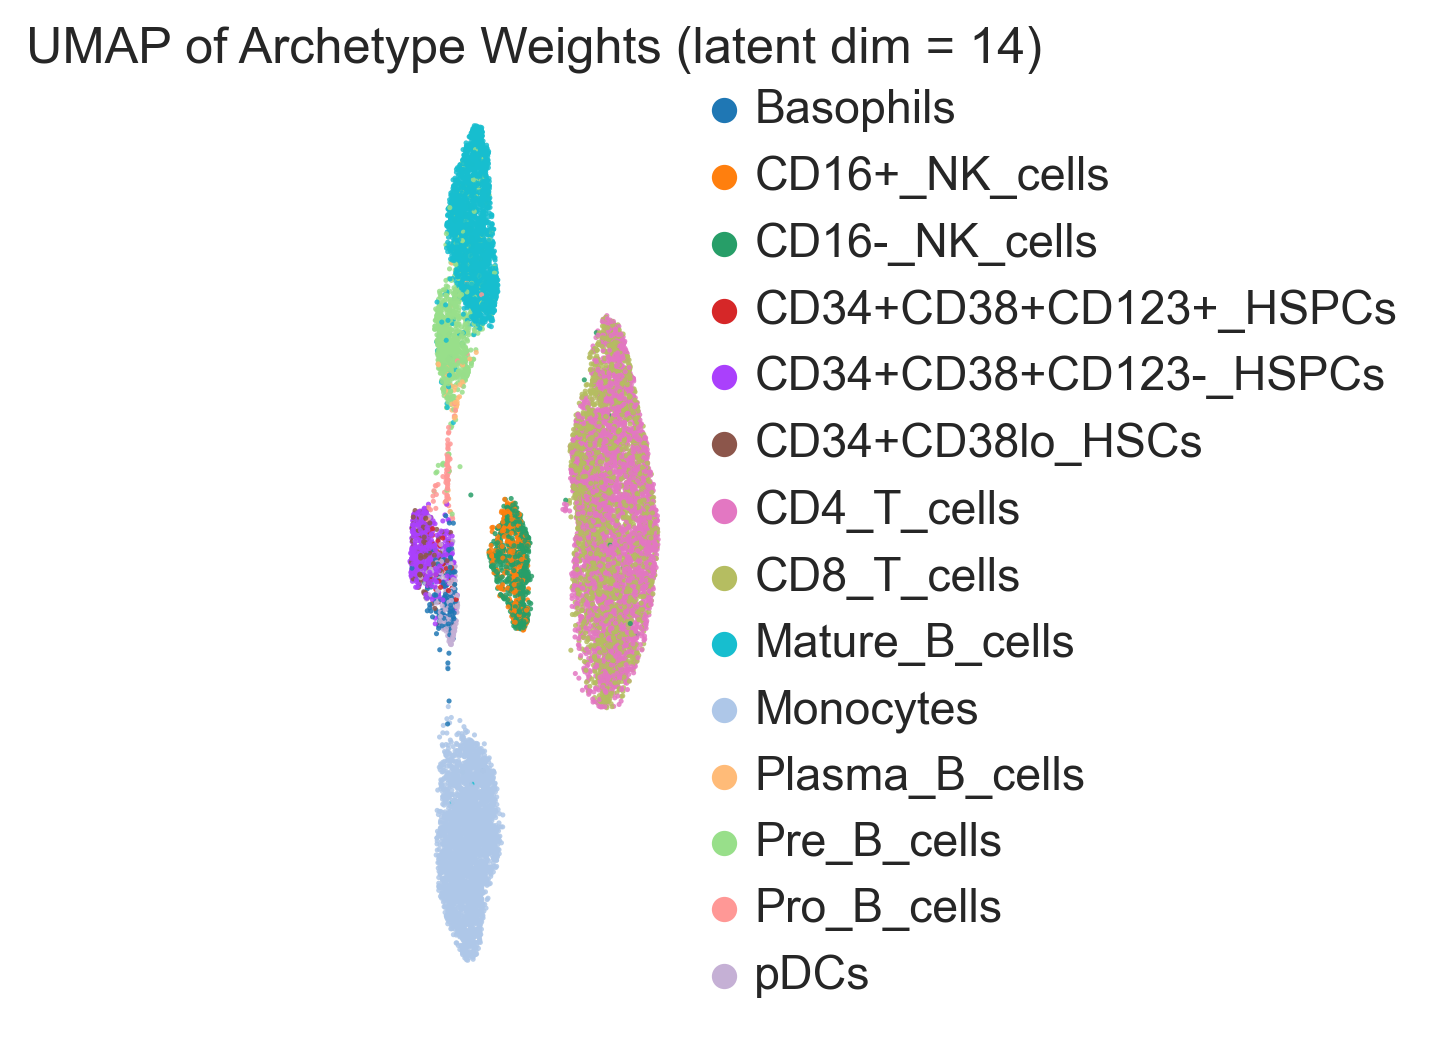

In [12]:
#print('\nPlotting Scanpy UMAP colored by cell type ...')
fig1 = sc.pl.umap(
    adata_deconv[adata_deconv.obs['cell_type']!='unassigned'],
    color='cell_type',
    title='UMAP of Archetype Weights (latent dim = 14)',
    frameon=False,
    size=8,
    alpha=0.85,
    legend_loc='right margin',
    show=False,
    return_fig=True,
)
display(fig1)
plt.close(fig1)

Plotting Scanpy UMAP colored by dominant archetype ...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


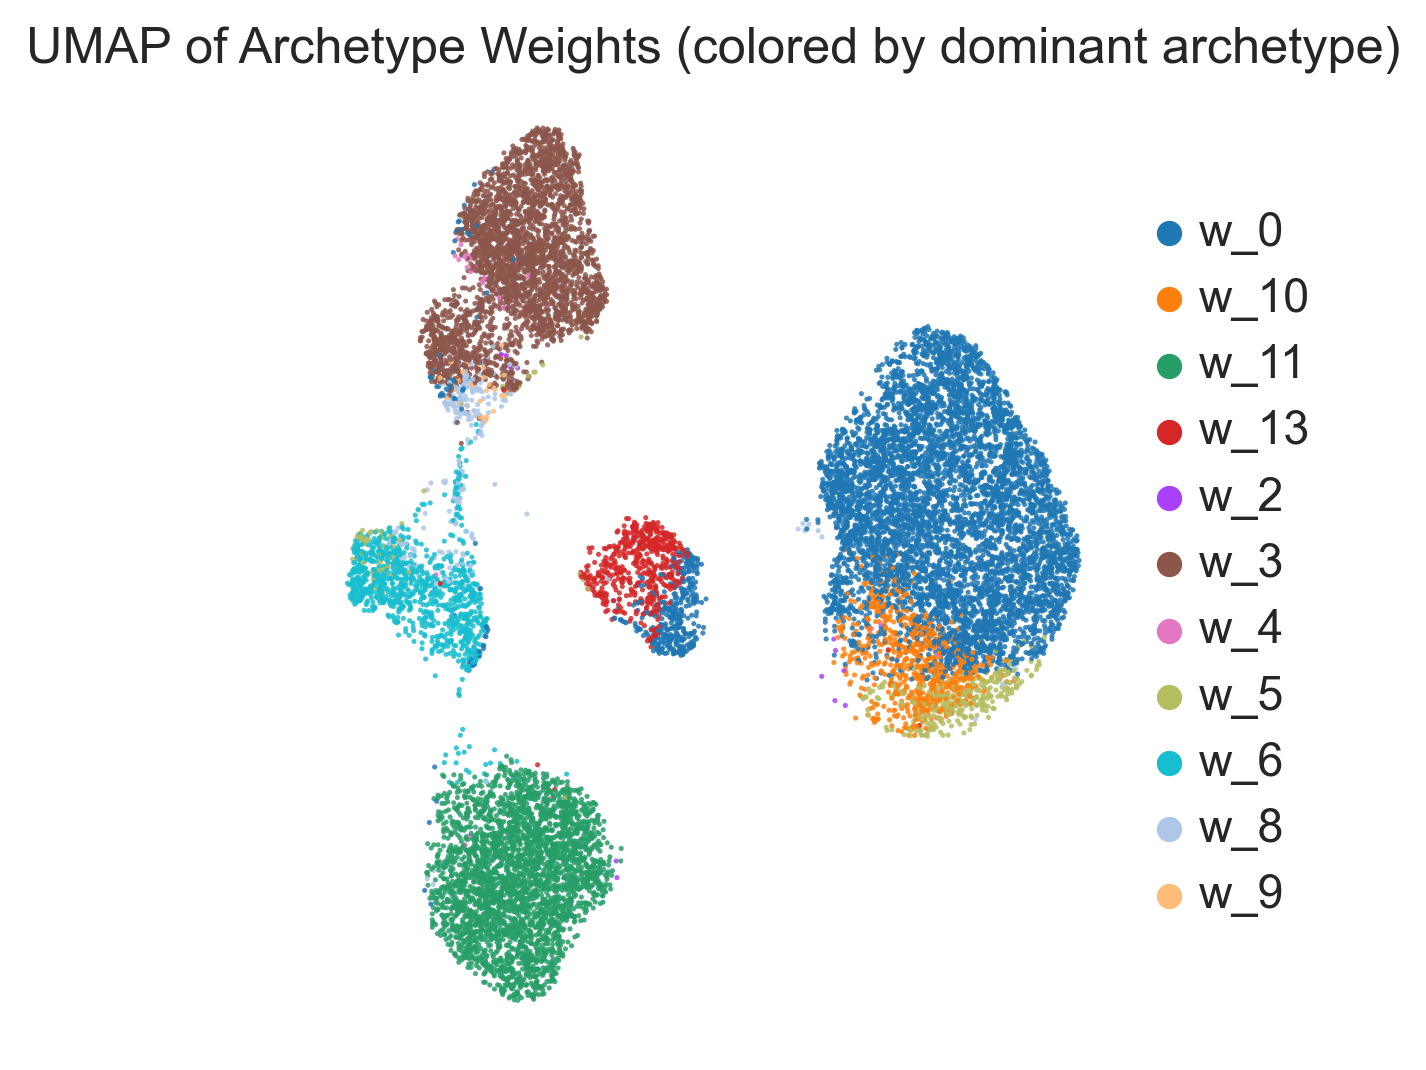

In [13]:
print('Plotting Scanpy UMAP colored by dominant archetype ...')
fig2 = sc.pl.umap(
    adata_deconv[adata_deconv.obs['cell_type']!='unassigned'],
    color='dominant_archetype',
    title='UMAP of Archetype Weights (colored by dominant archetype)',
    frameon=False,
    size=8,
    alpha=0.85,
    legend_loc='right margin',
    show=False,
    return_fig=True,
)
display(fig2)
plt.close(fig2)

## Next Steps

- Persist `adata_deconv` to disk (for example `.h5ad`) if you want to reuse the same obs/obsm structure across sessions.
- Compare this `latent dim = 14` run against `latent dim = 8` and `10` to assess over-fragmentation vs under-merging.
- Use the Scanpy UMAP views with heatmaps/histograms to interpret archetypes before making biological claims.
